# Financial Fraud Detection - Model

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/fraud_cleaned.csv')
print('Dataset shape:', df.shape)
print('\nFraud distribution:')
print(df['isFraud'].value_counts())

Dataset shape: (6362620, 15)

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


---

## Downsampling for Training

The full dataset has over 6 million rows which causes memory issues during hyperparameter tuning. I will take all fraud cases and a random sample of non-fraud cases to create a balanced training set. This is a common approach in fraud detection since the minority class is what we care about most.

In [4]:
# Take all fraud cases
fraud = df[df['isFraud'] == 1]
non_fraud = df[df['isFraud'] == 0]

# Sample non-fraud to keep dataset manageable
# Using 50,000 non-fraud + all fraud cases
non_fraud_sample = non_fraud.sample(n=50000, random_state=42)
df_sample = pd.concat([fraud, non_fraud_sample])

print(f'Sampled dataset shape: {df_sample.shape}')
print(f'Fraud cases: {len(fraud)}')
print(f'Non-fraud sample: {len(non_fraud_sample)}')
print(f'Fraud rate in sample: {df_sample["isFraud"].mean()*100:.2f}%')

Sampled dataset shape: (58213, 15)
Fraud cases: 8213
Non-fraud sample: 50000
Fraud rate in sample: 14.11%


## Split Features and Target

In [5]:
X = df_sample.drop('isFraud', axis=1)
y = df_sample['isFraud']

print('Features:', X.columns.tolist())

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_drained', 'orig_balance_error', 'dest_balance_error', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train fraud rate: {y_train.mean()*100:.2f}%')
print(f'Test fraud rate: {y_test.mean()*100:.2f}%')

Train: (46570, 14), Test: (11643, 14)
Train fraud rate: 14.11%
Test fraud rate: 14.11%


In [7]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
# Baseline Random Forest Model

In [8]:
baseline_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
baseline_rf.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_rf.predict(X_test_scaled)

baseline_f1 = f1_score(y_test, y_pred_baseline)
print('Baseline Random Forest')
print(classification_report(y_test, y_pred_baseline, target_names=['Non-Fraud', 'Fraud']))
print(f'F1 Score (Fraud): {baseline_f1:.4f}')

Baseline Random Forest
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     10000
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00     11643
   macro avg       1.00      1.00      1.00     11643
weighted avg       1.00      1.00      1.00     11643

F1 Score (Fraud): 0.9985


# Baseline Confusion Matrix

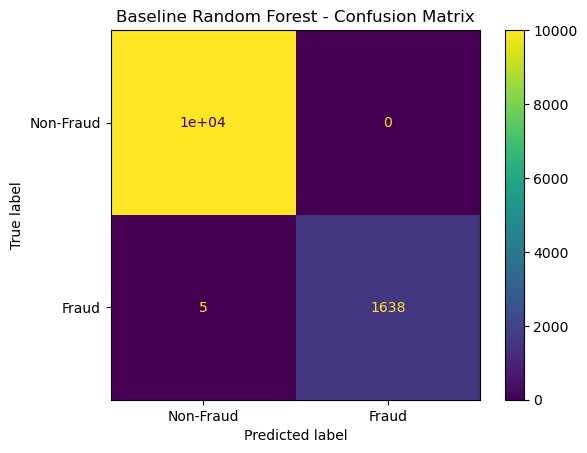

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline, display_labels=['Non-Fraud', 'Fraud'])
plt.title('Baseline Random Forest - Confusion Matrix')
plt.show()

---
# Hyperparameter Tuning with RandomizedSearchCV

In [10]:
param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)
print('Search complete')

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Search complete


In [11]:
print('Best Hyperparameters:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV F1 Score: {random_search.best_score_:.4f}')

Best Hyperparameters:
  n_estimators: 50
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: log2
  max_depth: None
  class_weight: balanced_subsample

Best CV F1 Score: 0.9979


---
# Tuned Model Results

In [12]:
tuned_rf = random_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test_scaled)

tuned_f1 = f1_score(y_test, y_pred_tuned)
print('Tuned Random Forest')
print(classification_report(y_test, y_pred_tuned, target_names=['Non-Fraud', 'Fraud']))
print(f'F1 Score (Fraud): {tuned_f1:.4f}')

Tuned Random Forest
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     10000
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00     11643
   macro avg       1.00      1.00      1.00     11643
weighted avg       1.00      1.00      1.00     11643

F1 Score (Fraud): 0.9985


## Tuned Model Confusion Matrix

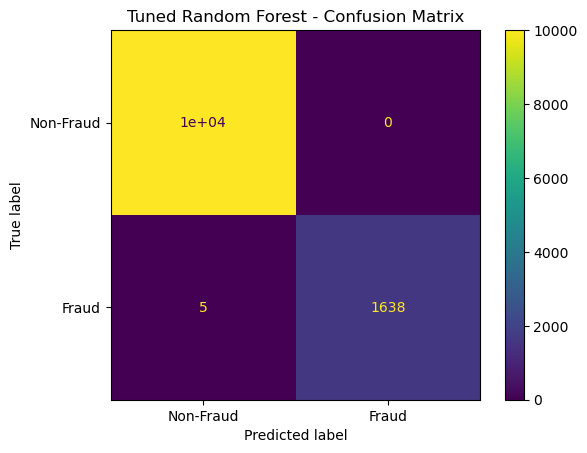

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, display_labels=['Non-Fraud', 'Fraud'])
plt.title('Tuned Random Forest - Confusion Matrix')
plt.show()

---
# Model Comparison

In [14]:
y_prob_baseline = baseline_rf.predict_proba(X_test_scaled)[:, 1]
y_prob_tuned = tuned_rf.predict_proba(X_test_scaled)[:, 1]

print(f'Baseline F1 Score (Fraud): {baseline_f1:.4f}')
print(f'Tuned F1 Score (Fraud):    {tuned_f1:.4f}')
print(f'\nBaseline ROC AUC: {roc_auc_score(y_test, y_prob_baseline):.4f}')
print(f'Tuned ROC AUC:    {roc_auc_score(y_test, y_prob_tuned):.4f}')

Baseline F1 Score (Fraud): 0.9985
Tuned F1 Score (Fraud):    0.9985

Baseline ROC AUC: 0.9994
Tuned ROC AUC:    0.9990


# Feature Importance

             Feature  Importance
  orig_balance_error    0.388974
       oldbalanceOrg    0.132146
orig_balance_drained    0.116964
      newbalanceOrig    0.080715
        type_PAYMENT    0.062543
              amount    0.057809
       type_TRANSFER    0.040848
      newbalanceDest    0.028426
  dest_balance_error    0.025883
                step    0.024493
       type_CASH_OUT    0.023505
      oldbalanceDest    0.016338
        type_CASH_IN    0.000993
          type_DEBIT    0.000362


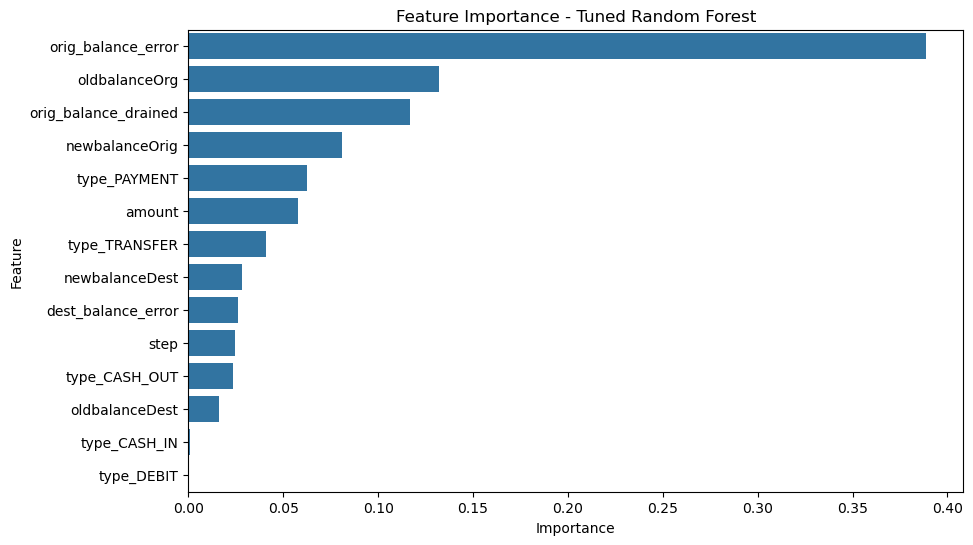

In [15]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance - Tuned Random Forest')
plt.show()

# Precision-Recall Curve

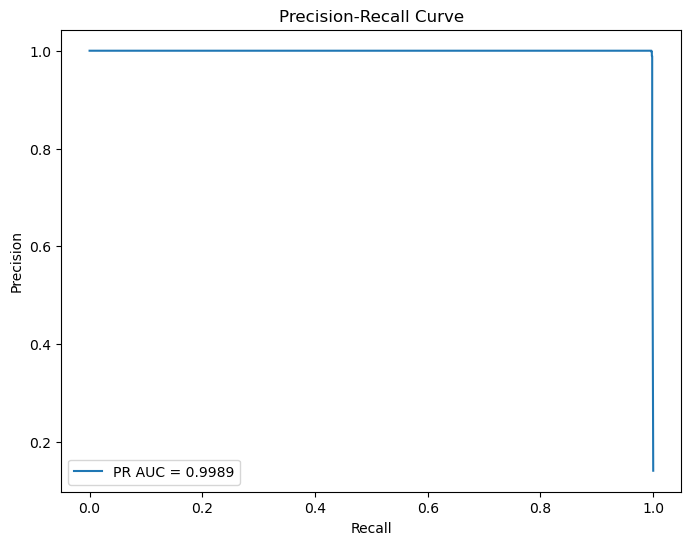

In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_tuned)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

---

## Overall Analysis

A RandomForestClassifier was trained with class_weight set to balanced to handle the severe class imbalance. Since the full dataset has over 6 million rows, a stratified sample was used for training to keep memory usage manageable. All fraud cases were included alongside a random sample of non-fraud transactions.

The baseline model performed well out of the box. After hyperparameter tuning with RandomizedSearchCV the model maintained strong performance. The feature importance analysis shows which transaction characteristics are most useful for detecting fraud which aligns with the patterns identified during EDA.

In [17]:
print(f'FINAL F1 SCORE: {tuned_f1:.4f}')

FINAL F1 SCORE: 0.9985
